In [2]:
# Importing Libraries
import pandas as pd
import numpy as np

In [3]:
#Load Data 
df=pd.read_csv(r"C:\Users\dassh\Downloads\Gaming Analytics & Economy Intelligence\Gaming_Dataset.csv")

In [4]:
df.head(10)

,Game_ID,Genre,Session_Date,Daily_Active_Sessions,Avg_Session_Duration,Levels_Completed,Coins_Earned,Coins_Spent,Ads_Revenue,InApp_Purchase_Revenue,Bug_Reports,Server_Downtime_Min
0,Game_C,Puzzle,2024-01-01,4805.0,55.0,154.0,4067.0,4744.0,NaN,NaN,44.0,10.0
1,Game_D,Puzzle,2024-01-02,3413.0,15.0,NaN,1023.0,3843.0,11340.0,10630.0,44.0,19.0
2,Game_A,Action,2024-01-03,3323.0,16.0,NaN,6134.0,2311.0,14408.0,2032.0,28.0,117.0
3,Game_C,Action,2024-01-04,3427.0,13.0,159.0,1675.0,671.0,19072.0,8108.0,48.0,55.0
4,Game_C,Puzzle,2024-01-05,4814.0,NaN,481.0,7668.0,4642.0,19460.0,11720.0,23.0,44.0
5,Game_D,Action,2024-01-06,2332.0,NaN,82.0,NaN,1125.0,2461.0,12909.0,14.0,67.0
6,Game_A,Action,2024-01-07,2654.0,15.0,403.0,6988.0,6406.0,10594.0,1940.0,5.0,46.0
7,Game_A,Puzzle,NaN,4339.0,57.0,280.0,8652.0,8483.0,1072.0,10090.0,31.0,NaN
8,Game_C,Action,2024-01-09,1944.0,40.0,366.0,9680.0,NaN,7030.0,4146.0,43.0,88.0
9,Game_B,Racing,2024-01-10,4856.0,14.0,315.0,2485.0,8642.0,8717.0,12089.0,33.0,119.0


In [5]:
# Data Cleaning 
# Check Nulls
df.isnull().sum()

Game_ID                   428
Genre                     423
Session_Date              439
Daily_Active_Sessions     435
Avg_Session_Duration      416
Levels_Completed          430
Coins_Earned              429
Coins_Spent               435
Ads_Revenue               427
InApp_Purchase_Revenue    433
Bug_Reports               423
Server_Downtime_Min       432
dtype: int64

In [15]:
# Fill categorical nulls
df['Game_ID'] = df['Game_ID'].fillna('Unknown')
df['Genre'] = df['Genre'].fillna('Unknown')

# Fill numeric nulls with median
num_cols = df.select_dtypes(include=np.number).columns

for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

# Convert date
df['Session_Date'] = pd.to_datetime(df['Session_Date'])
df['Session_Date'] = df['Session_Date'].fillna(df['Session_Date'].median())

# Remove duplicates
df = df.drop_duplicates()

In [16]:
df.isnull().sum()

Game_ID                   0
Genre                     0
Session_Date              0
Daily_Active_Sessions     0
Avg_Session_Duration      0
Levels_Completed          0
Coins_Earned              0
Coins_Spent               0
Ads_Revenue               0
InApp_Purchase_Revenue    0
Bug_Reports               0
Server_Downtime_Min       0
dtype: int64

In [17]:
import matplotlib.pyplot as plt

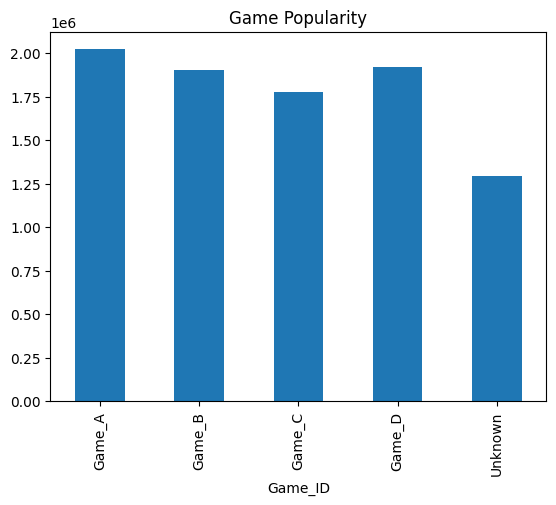

In [18]:
# Game popularity
df.groupby('Game_ID')['Daily_Active_Sessions'].sum().plot(kind='bar')
plt.title("Game Popularity")
plt.show()

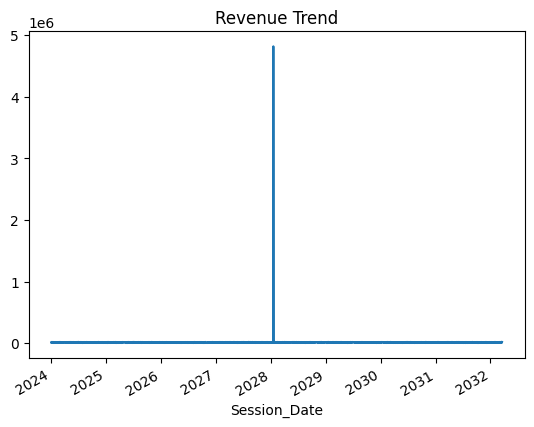

In [19]:
# Revenue trend
df.groupby('Session_Date')['Ads_Revenue'].sum().plot()
plt.title("Revenue Trend")
plt.show()

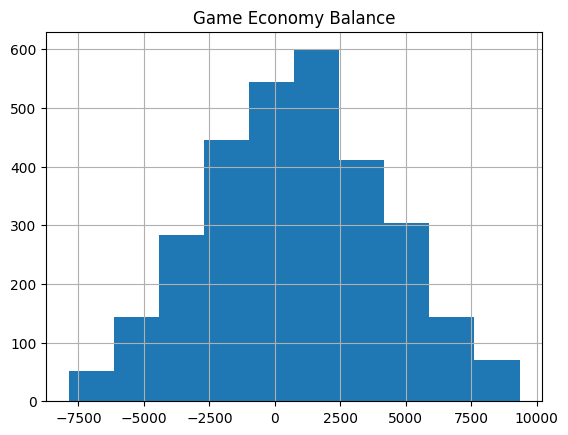

In [20]:
# Economy balance
df['Economy_Gap'] = df['Coins_Earned'] - df['Coins_Spent']

df['Economy_Gap'].hist()
plt.title("Game Economy Balance")
plt.show()

In [25]:
# Connecting Python Script to PostgreSQL

from sqlalchemy import create_engine
from urllib.parse import quote_plus

# DB credentials
username = "postgres"
password = quote_plus("Shiva@2001")
host = "localhost"
port = "5432"
database = "Gaming Analytics"

# Create connection
engine = create_engine(f"postgresql+psycopg2://{username}:{password}@{host}:{port}/{database}")

# Load to PostgreSQL
table_name = "gaming_data"

df.to_sql(table_name, engine, if_exists="replace", index=False)

print(f"Data successfully loaded into table '{table_name}' in database '{database}'.")

Data successfully loaded into table 'gaming_data' in database 'Gaming Analytics'.
